# World Cup Hangover Analysis

**Research theme:** Do teams that perform well in one FIFA World Cup systematically underperform in the next?

This revised notebook fixes several technical issues in the earlier version:

- Filters to **men's FIFA World Cups only** to match the project proposal.
- Uses `tournament_standings.csv` to correctly separate **champions, runners-up, and semifinalists**.
- Treats teams that fail to qualify for the next World Cup as `stage_score_next = 0` (`Did not qualify`), rather than silently dropping them.
- Builds FIFA rankings from `total_points` because the Dato-Futbol file does not include an explicit rank column.
- Avoids multicollinearity in the expectation-overperformance logistic model.
- Adds presentation-ready charts saved into `wc_hangover_charts/`.

**Data sources:**

1. Fjelstul World Cup Database from GitHub: `qualified_teams`, `squads`, `tournaments`, and `tournament_standings`.
2. Dato-Futbol FIFA historical rankings from GitHub: `ranking_fifa_historical.csv`.

No Kaggle datasets are used.

In [1]:
# Uncomment if your environment needs packages installed
# %pip install pandas numpy matplotlib scikit-learn statsmodels scipy

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

OUTPUT_DIR = Path('wc_hangover_charts')
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

## 1. Load non-Kaggle data

The cell below first looks for local CSV files in the notebook folder or `/mnt/data`. If they are not present, it downloads the public GitHub raw files.

In [3]:
WC_BASE = 'https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv'
DATASETS = {
    'qualified_teams.csv': f'{WC_BASE}/qualified_teams.csv',
    'squads.csv': f'{WC_BASE}/squads.csv',
    'tournaments.csv': f'{WC_BASE}/tournaments.csv',
    'tournament_standings.csv': f'{WC_BASE}/tournament_standings.csv',
    'ranking_fifa_historical.csv': 'https://raw.githubusercontent.com/Dato-Futbol/fifa-ranking/master/ranking_fifa_historical.csv'
}

def read_csv_flexible(filename, url):
    candidates = [Path(filename), Path('/mnt/data') / filename]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    return pd.read_csv(url)

qualified = read_csv_flexible('qualified_teams.csv', DATASETS['qualified_teams.csv'])
squads = read_csv_flexible('squads.csv', DATASETS['squads.csv'])
tournaments = read_csv_flexible('tournaments.csv', DATASETS['tournaments.csv'])
standings = read_csv_flexible('tournament_standings.csv', DATASETS['tournament_standings.csv'])
rankings = read_csv_flexible('ranking_fifa_historical.csv', DATASETS['ranking_fifa_historical.csv'])

print('qualified:', qualified.shape)
print('squads:', squads.shape)
print('tournaments:', tournaments.shape)
print('standings:', standings.shape)
print('rankings:', rankings.shape)

display(qualified.head())
display(rankings.head())

qualified: (625, 8)
squads: (13843, 12)
tournaments: (30, 18)
standings: (120, 7)
rankings: (67894, 6)


,key_id,tournament_id,tournament_name,team_id,team_name,team_code,count_matches,performance
0,1,WC-1930,1930 FIFA Men's World Cup,T-03,Argentina,ARG,5,final
1,2,WC-1930,1930 FIFA Men's World Cup,T-06,Belgium,BEL,2,group stage
2,3,WC-1930,1930 FIFA Men's World Cup,T-07,Bolivia,BOL,2,group stage
3,4,WC-1930,1930 FIFA Men's World Cup,T-09,Brazil,BRA,2,group stage
4,5,WC-1930,1930 FIFA Men's World Cup,T-13,Chile,CHL,3,group stage


,team,total_points,date,id,id_num,team_short
0,Argentina,1855.20,2024-02-15,id14289,14289,ARG
1,France,1845.44,2024-02-15,id14289,14289,FRA
2,England,1800.05,2024-02-15,id14289,14289,ENG
3,Belgium,1798.46,2024-02-15,id14289,14289,BEL
4,Brazil,1784.09,2024-02-15,id14289,14289,BRA


## 2. Filter to men's World Cups and standardize teams

The Fjelstul database includes both men's and women's tournaments. This project is about the men's FIFA World Cup from 1930–2022, so the analysis filters to `tournament_name` containing `Men's`.

In [4]:
def normalize_country(x):
    # Normalize a few common naming differences between the World Cup and FIFA ranking datasets.
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    replacements = {
        'United States': 'USA',
        'United States of America': 'USA',
        'South Korea': 'Korea Republic',
        'North Korea': 'Korea DPR',
        'Iran': 'IR Iran',
        'Türkiye': 'Turkey',
        'Czechia': 'Czech Republic',
        'Ivory Coast': "Côte d'Ivoire",
        'West Germany': 'Germany',
        'Republic of Ireland': 'Ireland',
        'Russian Federation': 'Russia'
    }
    return replacements.get(x, x)

men_tournaments = tournaments[tournaments['tournament_name'].str.contains("Men's", na=False)].copy()
men_ids = set(men_tournaments['tournament_id'])

qualified = qualified[qualified['tournament_id'].isin(men_ids)].copy()
squads = squads[squads['tournament_id'].isin(men_ids)].copy()
standings = standings[standings['tournament_id'].isin(men_ids)].copy()

qualified = qualified.merge(men_tournaments[['tournament_id', 'year', 'start_date', 'winner']], on='tournament_id', how='left')
standings = standings.merge(men_tournaments[['tournament_id', 'year', 'start_date']], on='tournament_id', how='left')
squads = squads.merge(men_tournaments[['tournament_id', 'year', 'start_date']], on='tournament_id', how='left')

qualified['team_key'] = qualified['team_name'].map(normalize_country)
standings['team_key'] = standings['team_name'].map(normalize_country)
squads['team_key'] = squads['team_name'].map(normalize_country)

print('Men tournaments:', men_tournaments['year'].nunique())
print(sorted(men_tournaments['year'].astype(int).unique()))
print('Qualified team-year rows:', len(qualified))
display(qualified[['year', 'team_name', 'team_key', 'performance']].head())

Men tournaments: 22
[np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
Qualified team-year rows: 489


,year,team_name,team_key,performance
0,1930,Argentina,Argentina,final
1,1930,Belgium,Belgium,group stage
2,1930,Bolivia,Bolivia,group stage
3,1930,Brazil,Brazil,group stage
4,1930,Chile,Chile,group stage


## 3. Create ordinal stage scores

The original notebook treated `performance = final` as ambiguous, which caused champions and runners-up to be misclassified. Here, `tournament_standings.csv` fixes the top four:

| Score | Meaning |
|---:|---|
| 0 | Did not qualify for next tournament |
| 1 | Group stage |
| 2 | Second group stage / final round |
| 3 | Round of 16 |
| 4 | Quarterfinal |
| 5 | Semifinalist / 3rd or 4th place |
| 6 | Runner-up |
| 7 | Champion |

In [5]:
base_score_map = {
    'group stage': 1,
    'second group stage': 2,
    'round of 16': 3,
    'quarter-final': 4,
    'quarter-finals': 4,
    'semi-finals': 5,
    'third-place match': 5,
    'final round': 5,
    'final': 6,
}

position_df = standings[['tournament_id', 'team_key', 'position']].copy()
qualified = qualified.merge(position_df, on=['tournament_id', 'team_key'], how='left')
qualified['base_stage_score'] = qualified['performance'].map(base_score_map)
qualified['stage_score'] = qualified['base_stage_score']
qualified.loc[qualified['position'] == 1, 'stage_score'] = 7
qualified.loc[qualified['position'] == 2, 'stage_score'] = 6
qualified.loc[qualified['position'].isin([3, 4]), 'stage_score'] = 5

stage_labels = {
    0: 'Did not qualify',
    1: 'Group stage',
    2: 'Second group',
    3: 'Round of 16',
    4: 'Quarterfinal',
    5: 'Semifinalist',
    6: 'Runner-up',
    7: 'Champion'
}
qualified['stage_tier'] = qualified['stage_score'].map(stage_labels)

stage_check = qualified.groupby(['performance', 'stage_score'], dropna=False).size().reset_index(name='count')
display(stage_check.sort_values(['stage_score', 'performance']))

wc_team_year = qualified[[
    'team_key', 'team_name', 'team_code', 'tournament_id', 'year', 'start_date',
    'performance', 'position', 'stage_score', 'stage_tier'
]].copy()
wc_team_year['year'] = wc_team_year['year'].astype(int)
wc_team_year['start_date'] = pd.to_datetime(wc_team_year['start_date'])

display(wc_team_year.head())

,performance,stage_score,count
5,group stage,1,222
8,second group stage,2,16
7,round of 16,3,95
6,quarter-finals,4,68
2,final round,5,2
9,semi-finals,5,2
10,third-place match,5,40
0,final,6,21
3,final round,6,1
1,final,7,21


,team_key,team_name,team_code,tournament_id,year,start_date,performance,position,stage_score,stage_tier
0,Argentina,Argentina,ARG,WC-1930,1930,1930-07-13,final,2.0,6,Runner-up
1,Belgium,Belgium,BEL,WC-1930,1930,1930-07-13,group stage,NaN,1,Group stage
2,Bolivia,Bolivia,BOL,WC-1930,1930,1930-07-13,group stage,NaN,1,Group stage
3,Brazil,Brazil,BRA,WC-1930,1930,1930-07-13,group stage,NaN,1,Group stage
4,Chile,Chile,CHL,WC-1930,1930,1930-07-13,group stage,NaN,1,Group stage


## 4. Build tournament N → tournament N+1 pairs

This version includes teams that qualified in tournament N but **did not qualify** in tournament N+1. Those cases receive `stage_score_next = 0`, which is important for measuring underperformance rather than dropping the most severe drop-offs.

In [6]:
years = sorted(men_tournaments['year'].astype(int).unique())
next_year_map = {y: years[i+1] for i, y in enumerate(years[:-1])}

base = wc_team_year[wc_team_year['year'].isin(years[:-1])].copy()
base['next_year'] = base['year'].map(next_year_map)

next_perf = wc_team_year[[
    'team_key', 'year', 'stage_score', 'stage_tier', 'performance', 'position'
]].rename(columns={
    'year': 'next_year',
    'stage_score': 'stage_score_next',
    'stage_tier': 'stage_tier_next',
    'performance': 'performance_next',
    'position': 'position_next'
})

pairs = base.merge(next_perf, on=['team_key', 'next_year'], how='left')
pairs['qualified_next'] = pairs['stage_score_next'].notna().astype(int)
pairs['stage_score_next'] = pairs['stage_score_next'].fillna(0).astype(int)
pairs['stage_tier_next'] = pairs['stage_tier_next'].fillna('Did not qualify')
pairs['delta_stage'] = pairs['stage_score_next'] - pairs['stage_score']
pairs['underperform_next'] = (pairs['delta_stage'] < 0).astype(int)

def prior_status_from_position(pos):
    if pd.isna(pos):
        return 'Other'
    pos = int(pos)
    if pos == 1:
        return 'Champion'
    if pos == 2:
        return 'Runner-up'
    if pos in [3, 4]:
        return 'Semifinalist'
    return 'Other'

pairs['prior_status'] = pairs['position'].map(prior_status_from_position)

print('N→N+1 observations:', pairs.shape[0])
print('Unique teams:', pairs['team_key'].nunique())
print('Share underperforming:', round(pairs['underperform_next'].mean(), 3))
print('\nPrior-status counts:')
print(pairs['prior_status'].value_counts())

display(pairs[['team_key', 'year', 'next_year', 'stage_tier', 'stage_tier_next', 'delta_stage', 'underperform_next', 'prior_status']].head(12))

N→N+1 observations: 457
Unique teams: 83
Share underperforming: 0.589

Prior-status counts:
prior_status
Other           373
Semifinalist     42
Runner-up        21
Champion         21
Name: count, dtype: int64


,team_key,year,next_year,stage_tier,stage_tier_next,delta_stage,underperform_next,prior_status
0,Argentina,1930,1934,Runner-up,Round of 16,-3,1,Runner-up
1,Belgium,1930,1934,Group stage,Round of 16,2,0,Other
2,Bolivia,1930,1934,Group stage,Did not qualify,-1,1,Other
3,Brazil,1930,1934,Group stage,Round of 16,2,0,Other
4,Chile,1930,1934,Group stage,Did not qualify,-1,1,Other
5,France,1930,1934,Group stage,Round of 16,2,0,Other
6,Mexico,1930,1934,Group stage,Did not qualify,-1,1,Other
7,Paraguay,1930,1934,Group stage,Did not qualify,-1,1,Other
8,Peru,1930,1934,Group stage,Did not qualify,-1,1,Other
9,Romania,1930,1934,Group stage,Round of 16,2,0,Other


## 5. Add squad turnover / player retention

Retention = players from tournament N who are also in the same team squad in N+1, divided by squad size in N.

This variable is only available when the team qualified in both N and N+1.

In [7]:
squads['player_key'] = squads['player_id'].astype(str)
squads['year'] = squads['year'].astype(int)

squad_sets = squads.groupby(['team_key', 'year'])['player_key'].apply(lambda x: set(x.dropna())).to_dict()

def retention(row):
    if row['qualified_next'] != 1:
        return np.nan
    current = squad_sets.get((row['team_key'], int(row['year'])), set())
    nxt = squad_sets.get((row['team_key'], int(row['next_year'])), set())
    if len(current) == 0 or len(nxt) == 0:
        return np.nan
    return len(current.intersection(nxt)) / len(current)

pairs['player_retention'] = pairs.apply(retention, axis=1)
pairs['squad_turnover'] = 1 - pairs['player_retention']

print('Rows with squad turnover:', pairs['squad_turnover'].notna().sum())
display(pairs[['team_key', 'year', 'next_year', 'player_retention', 'squad_turnover']].dropna().head())

Rows with squad turnover: 276


,team_key,year,next_year,player_retention,squad_turnover
0,Argentina,1930,1934,0.000000,1.000000
1,Belgium,1930,1934,0.250000,0.750000
3,Brazil,1930,1934,0.083333,0.916667
5,France,1930,1934,0.375000,0.625000
9,Romania,1930,1934,0.133333,0.866667


## 6. Add FIFA rankings before tournament N and N+1

The Dato-Futbol file contains `total_points`, not a `rank` column. We create ranks by sorting total points within each ranking date. Lower rank = stronger team.

In [8]:
rankings['date'] = pd.to_datetime(rankings['date'])
rankings['team_key'] = rankings['team'].map(normalize_country)
rankings['points_num'] = pd.to_numeric(rankings['total_points'], errors='coerce')
rankings = rankings.dropna(subset=['points_num']).copy()

# Higher points = better rank. Rank 1 has the most points on that date.
rankings['rank_num'] = rankings.groupby('date')['points_num'].rank(ascending=False, method='min')

year_to_start = men_tournaments.set_index('year')['start_date'].apply(pd.to_datetime).to_dict()
team_years = []
for _, row in pairs.iterrows():
    team_years.append((row['team_key'], int(row['year'])))
    team_years.append((row['team_key'], int(row['next_year'])))
team_years = sorted(set(team_years))

ranking_records = []
for team, year in team_years:
    cutoff = pd.Timestamp(year_to_start[year])
    sub = rankings[(rankings['team_key'] == team) & (rankings['date'] <= cutoff)]
    if len(sub) > 0:
        last = sub.sort_values('date').iloc[-1]
        ranking_records.append({
            'team_key': team,
            'year': year,
            'fifa_rank': float(last['rank_num']),
            'fifa_points': float(last['points_num']),
            'ranking_date': last['date']
        })

rank_team_year = pd.DataFrame(ranking_records)

pairs = pairs.merge(rank_team_year, on=['team_key', 'year'], how='left')
pairs = pairs.merge(
    rank_team_year.rename(columns={
        'year': 'next_year',
        'fifa_rank': 'fifa_rank_next',
        'fifa_points': 'fifa_points_next',
        'ranking_date': 'ranking_date_next'
    }),
    on=['team_key', 'next_year'],
    how='left'
)

pairs['fifa_rank_change'] = pairs['fifa_rank_next'] - pairs['fifa_rank']  # positive = worse ranking
pairs['fifa_points_change'] = pairs['fifa_points_next'] - pairs['fifa_points']

print('Rows with FIFA rank before N:', pairs['fifa_rank'].notna().sum())
print('Rows with FIFA rank before both N and N+1:', pairs[['fifa_rank', 'fifa_rank_next']].dropna().shape[0])
display(pairs[['team_key', 'year', 'next_year', 'stage_tier', 'stage_tier_next', 'fifa_rank', 'fifa_rank_next', 'fifa_rank_change']].dropna().head())

Rows with FIFA rank before N: 215
Rows with FIFA rank before both N and N+1: 215


,team_key,year,next_year,stage_tier,stage_tier_next,fifa_rank,fifa_rank_next,fifa_rank_change
241,Argentina,1994,1998,Round of 16,Quarterfinal,7.0,5.0,-2.0
242,Belgium,1994,1998,Round of 16,Group stage,26.0,35.0,9.0
243,Bolivia,1994,1998,Group stage,Did not qualify,42.0,33.0,-9.0
244,Brazil,1994,1998,Champion,Runner-up,2.0,1.0,-1.0
245,Bulgaria,1994,1998,Semifinalist,Group stage,26.0,35.0,9.0


## 7. Exploratory charts for presentation

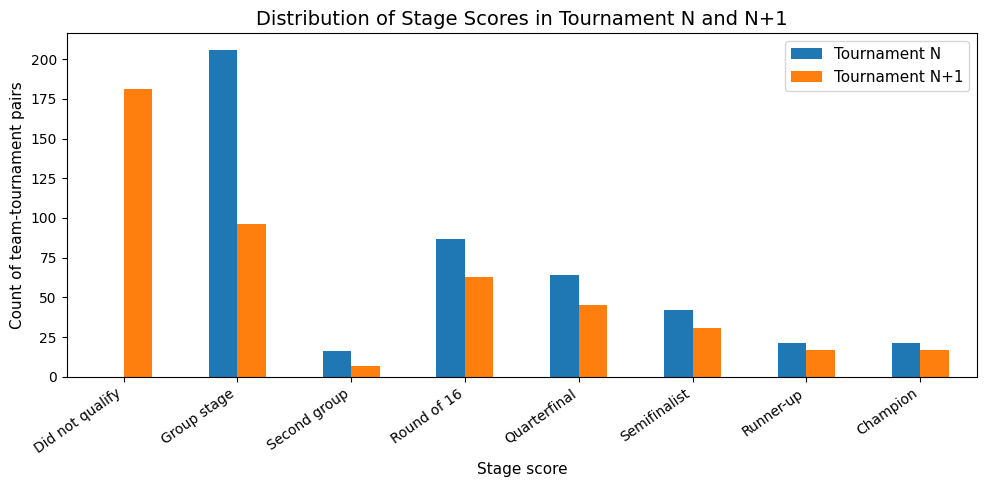

In [9]:
# Chart 1: Stage score distribution in tournament N and N+1
stage_counts = pd.DataFrame({
    'Tournament N': pairs['stage_score'].value_counts().sort_index(),
    'Tournament N+1': pairs['stage_score_next'].value_counts().sort_index()
}).fillna(0)
stage_counts.index = [stage_labels.get(int(i), str(i)) for i in stage_counts.index]

ax = stage_counts.plot(kind='bar', figsize=(10, 5))
plt.title('Distribution of Stage Scores in Tournament N and N+1')
plt.ylabel('Count of team-tournament pairs')
plt.xlabel('Stage score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_stage_score_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

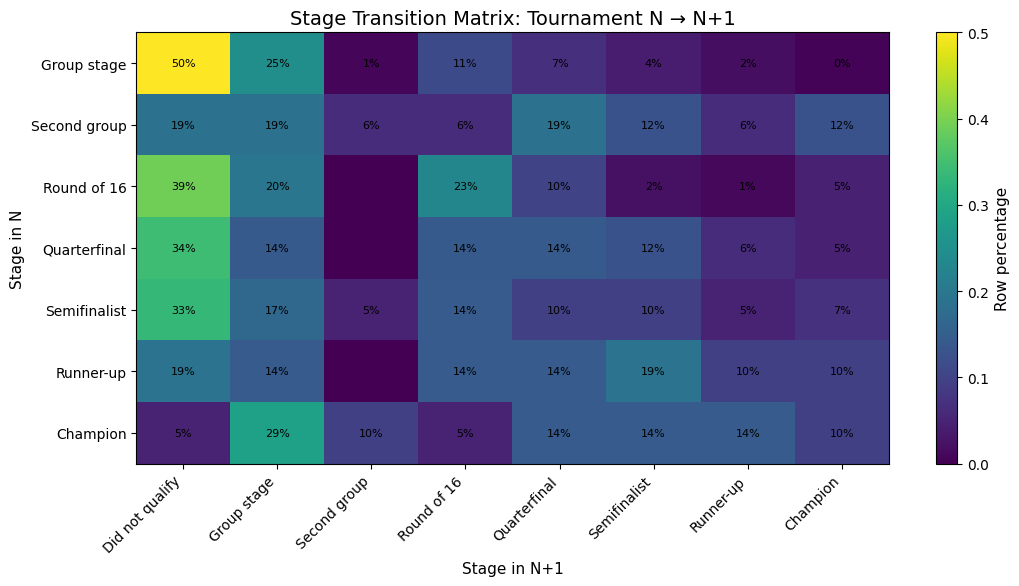

In [10]:
# Chart 2: Transition matrix from tournament N to N+1
stage_order = list(range(0, 8))
transition = pd.crosstab(pairs['stage_score'], pairs['stage_score_next']).reindex(index=stage_order[1:], columns=stage_order, fill_value=0)
transition_pct = transition.div(transition.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(transition_pct.values, aspect='auto')
ax.set_title('Stage Transition Matrix: Tournament N → N+1')
ax.set_xlabel('Stage in N+1')
ax.set_ylabel('Stage in N')
ax.set_xticks(range(len(stage_order)))
ax.set_xticklabels([stage_labels[i] for i in stage_order], rotation=45, ha='right')
ax.set_yticks(range(len(stage_order[1:])))
ax.set_yticklabels([stage_labels[i] for i in stage_order[1:]])
for i in range(transition_pct.shape[0]):
    for j in range(transition_pct.shape[1]):
        val = transition_pct.iloc[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Row percentage')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_stage_transition_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

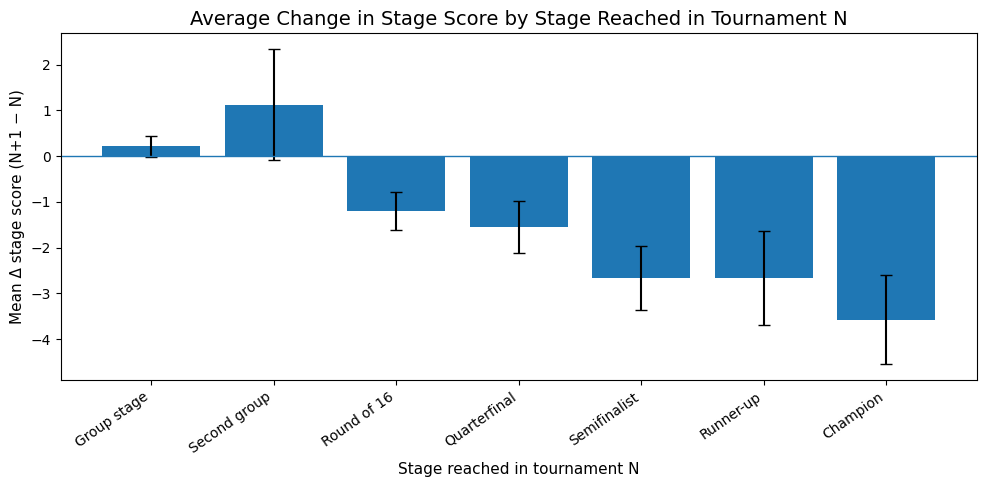

,stage_label,count,mean,ci95
0,Group stage,206,0.218447,0.229138
1,Second group,16,1.125000,1.211863
2,Round of 16,87,-1.195402,0.417620
3,Quarterfinal,64,-1.546875,0.569043
4,Semifinalist,42,-2.666667,0.705856
5,Runner-up,21,-2.666667,1.024118
6,Champion,21,-3.571429,0.980666


In [11]:
# Chart 3: Average performance change by stage reached in N
stage_summary = pairs.groupby('stage_score')['delta_stage'].agg(['count', 'mean', 'std']).reset_index()
stage_summary['se'] = stage_summary['std'] / np.sqrt(stage_summary['count'])
stage_summary['ci95'] = 1.96 * stage_summary['se']
stage_summary['stage_label'] = stage_summary['stage_score'].map(stage_labels)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(stage_summary['stage_label'], stage_summary['mean'], yerr=stage_summary['ci95'], capsize=4)
ax.axhline(0, linewidth=1)
ax.set_title('Average Change in Stage Score by Stage Reached in Tournament N')
ax.set_ylabel('Mean Δ stage score (N+1 − N)')
ax.set_xlabel('Stage reached in tournament N')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_delta_by_prior_stage.png', dpi=200, bbox_inches='tight')
plt.show()

display(stage_summary[['stage_label', 'count', 'mean', 'ci95']])

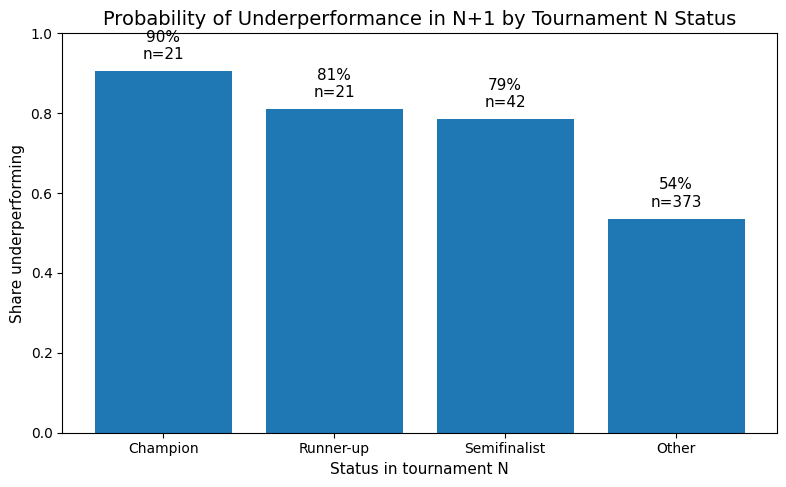

,count,mean
prior_status,,
Champion,21,0.904762
Runner-up,21,0.809524
Semifinalist,42,0.785714
Other,373,0.536193


In [12]:
# Chart 4: Underperformance probability by prior status
status_order = ['Champion', 'Runner-up', 'Semifinalist', 'Other']
status_under = pairs.groupby('prior_status')['underperform_next'].agg(['count', 'mean']).reindex(status_order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(status_under.index, status_under['mean'])
ax.set_ylim(0, 1)
ax.set_title('Probability of Underperformance in N+1 by Tournament N Status')
ax.set_ylabel('Share underperforming')
ax.set_xlabel('Status in tournament N')
for i, (idx, row) in enumerate(status_under.iterrows()):
    ax.text(i, row['mean'] + 0.03, f"{row['mean']:.0%}\nn={int(row['count'])}", ha='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_underperformance_by_status.png', dpi=200, bbox_inches='tight')
plt.show()

display(status_under)

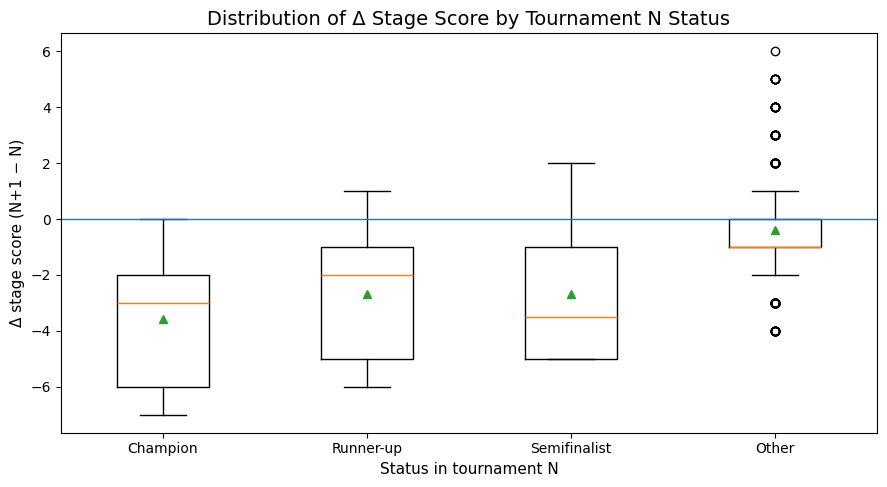

In [13]:
# Chart 5: Delta-stage boxplot by prior status
box_data = [pairs.loc[pairs['prior_status'] == s, 'delta_stage'].dropna().values for s in status_order]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(box_data, labels=status_order, showmeans=True)
ax.axhline(0, linewidth=1)
ax.set_title('Distribution of Δ Stage Score by Tournament N Status')
ax.set_ylabel('Δ stage score (N+1 − N)')
ax.set_xlabel('Status in tournament N')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_delta_boxplot_by_status.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Create “exceeded expectations” variable

A team exceeds expectations when its actual stage score in tournament N is higher than expected based on its FIFA ranking before that tournament.

Technical note: after creating `expectation_residual = actual stage − expected stage`, do **not** include both `stage_score` and `fifa_rank` in the same logistic model with the residual, because the residual is constructed from those variables.

In [14]:
ranked_pairs = pairs.dropna(subset=['fifa_rank', 'stage_score']).copy()
expect_model = smf.ols('stage_score ~ fifa_rank', data=ranked_pairs).fit()
ranked_pairs['expected_stage_from_rank'] = expect_model.predict(ranked_pairs)
ranked_pairs['expectation_residual'] = ranked_pairs['stage_score'] - ranked_pairs['expected_stage_from_rank']
ranked_pairs['exceeded_expectations'] = (ranked_pairs['expectation_residual'] > 0).astype(int)

pairs = pairs.merge(
    ranked_pairs[['team_key', 'year', 'expected_stage_from_rank', 'expectation_residual', 'exceeded_expectations']],
    on=['team_key', 'year'],
    how='left'
)

print(expect_model.summary())
display(ranked_pairs[['team_key', 'year', 'stage_score', 'stage_tier', 'fifa_rank', 'expected_stage_from_rank', 'expectation_residual', 'exceeded_expectations', 'underperform_next']].head())

                            OLS Regression Results                            
Dep. Variable:            stage_score   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     37.72
Date:                Sun, 03 May 2026   Prob (F-statistic):           3.96e-09
Time:                        16:14:19   Log-Likelihood:                -402.01
No. Observations:                 215   AIC:                             808.0
Df Residuals:                     213   BIC:                             814.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3701      0.174     19.370      0.0

,team_key,year,stage_score,stage_tier,fifa_rank,expected_stage_from_rank,expectation_residual,exceeded_expectations,underperform_next
241,Argentina,1994,3,Round of 16,7.0,3.107943,-0.107943,0,0
242,Belgium,1994,3,Round of 16,26.0,2.396258,0.603742,1,1
243,Bolivia,1994,1,Group stage,42.0,1.796944,-0.796944,0,1
244,Brazil,1994,7,Champion,2.0,3.295229,3.704771,1,1
245,Bulgaria,1994,5,Semifinalist,26.0,2.396258,2.603742,1,1


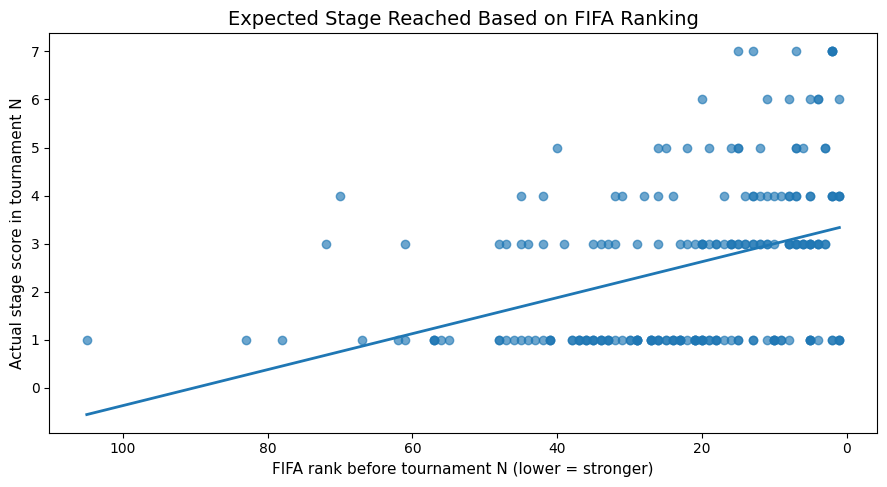

In [15]:
# Chart 6: FIFA rank versus actual stage score
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(ranked_pairs['fifa_rank'], ranked_pairs['stage_score'], alpha=0.65)
xs = np.linspace(ranked_pairs['fifa_rank'].min(), ranked_pairs['fifa_rank'].max(), 100)
ys = expect_model.params['Intercept'] + expect_model.params['fifa_rank'] * xs
ax.plot(xs, ys, linewidth=2)
ax.invert_xaxis()
ax.set_title('Expected Stage Reached Based on FIFA Ranking')
ax.set_xlabel('FIFA rank before tournament N (lower = stronger)')
ax.set_ylabel('Actual stage score in tournament N')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_fifa_rank_vs_stage.png', dpi=200, bbox_inches='tight')
plt.show()

# Question 1: Logistic Regression

**Is the probability of underperformance in N+1 higher for teams that exceeded expectations in N relative to their FIFA ranking?**

In [16]:
q1 = pairs.dropna(subset=['underperform_next', 'expectation_residual', 'fifa_rank']).copy()

# Main model: residual overperformance plus FIFA ranking control.
q1_logit = smf.logit('underperform_next ~ expectation_residual + fifa_rank', data=q1).fit(disp=False)
print(q1_logit.summary())

q1_odds = pd.DataFrame({
    'coef': q1_logit.params,
    'odds_ratio': np.exp(q1_logit.params),
    'p_value': q1_logit.pvalues
})
display(q1_odds)

# Alternative, easier-to-explain model using a binary overperformance flag.
q1_binary = smf.logit('underperform_next ~ exceeded_expectations + fifa_rank', data=q1).fit(disp=False)
print(q1_binary.summary())

display(pd.DataFrame({
    'coef': q1_binary.params,
    'odds_ratio': np.exp(q1_binary.params),
    'p_value': q1_binary.pvalues
}))

                           Logit Regression Results                           
Dep. Variable:      underperform_next   No. Observations:                  215
Model:                          Logit   Df Residuals:                      212
Method:                           MLE   Df Model:                            2
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1330
Time:                        16:14:19   Log-Likelihood:                -128.13
converged:                       True   LL-Null:                       -147.79
Covariance Type:            nonrobust   LLR p-value:                 2.896e-09
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.2099      0.257     -0.817      0.414      -0.713       0.293
expectation_residual     0.5871      0.113      5.213      0.000       0.366       0.808
fifa_rank   

,coef,odds_ratio,p_value
Intercept,-0.209911,0.810657,4.136487e-01
expectation_residual,0.587065,1.798701,1.855181e-07
fifa_rank,0.022165,1.022413,2.252923e-02


                           Logit Regression Results                           
Dep. Variable:      underperform_next   No. Observations:                  215
Model:                          Logit   Df Residuals:                      212
Method:                           MLE   Df Model:                            2
Date:                Sun, 03 May 2026   Pseudo R-squ.:                  0.1107
Time:                        16:14:19   Log-Likelihood:                -131.44
converged:                       True   LL-Null:                       -147.79
Covariance Type:            nonrobust   LLR p-value:                 7.866e-08
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.0366      0.309     -3.357      0.001      -1.642      -0.431
exceeded_expectations     1.5608      0.312      5.003      0.000       0.949       2.172
fifa_ran

,coef,odds_ratio,p_value
Intercept,-1.036611,0.354655,7.865714e-04
exceeded_expectations,1.560814,4.762697,5.656244e-07
fifa_rank,0.026491,1.026845,7.138126e-03


In [17]:
# Cross-validated predictive check for Question 1
X1 = q1[['expectation_residual', 'fifa_rank']]
y1 = q1['underperform_next']
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=1000))
])

if y1.value_counts().min() >= 3:
    cv = StratifiedKFold(n_splits=min(5, y1.value_counts().min()), shuffle=True, random_state=42)
    auc_scores = cross_val_score(clf, X1, y1, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(clf, X1, y1, cv=cv, scoring='accuracy')
    print('CV Accuracy:', round(acc_scores.mean(), 3), '+/-', round(acc_scores.std(), 3))
    print('CV AUC:', round(auc_scores.mean(), 3), '+/-', round(auc_scores.std(), 3))
else:
    print('Not enough class balance for cross-validated AUC.')

CV Accuracy: 0.67 +/- 0.054
CV AUC: 0.727 +/- 0.054


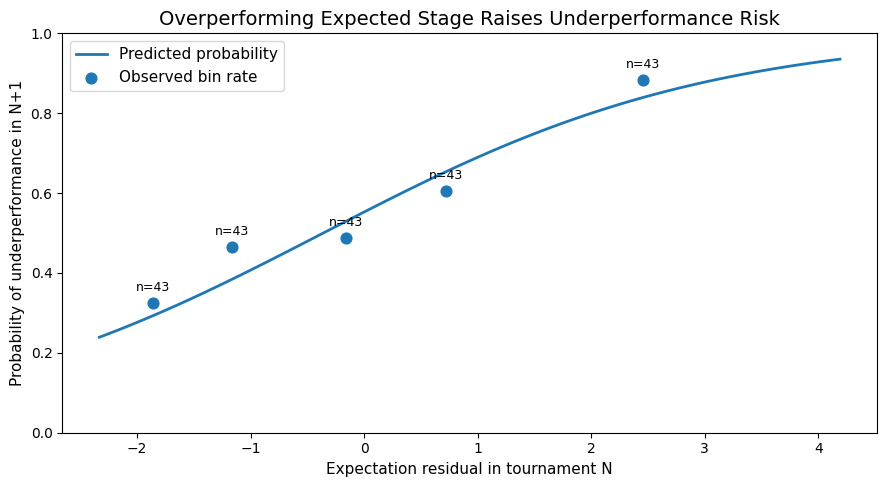

In [18]:
# Chart 7: Expectation residual and underperformance probability
resid_range = np.linspace(q1['expectation_residual'].min(), q1['expectation_residual'].max(), 100)
pred_df = pd.DataFrame({
    'expectation_residual': resid_range,
    'fifa_rank': q1['fifa_rank'].median()
})
pred_df['pred_prob'] = q1_logit.predict(pred_df)

# Observed rate by residual quintile
q1['residual_bin'] = pd.qcut(q1['expectation_residual'], q=5, duplicates='drop')
obs = q1.groupby('residual_bin').agg(
    mean_residual=('expectation_residual', 'mean'),
    underperform_rate=('underperform_next', 'mean'),
    count=('underperform_next', 'size')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pred_df['expectation_residual'], pred_df['pred_prob'], linewidth=2, label='Predicted probability')
ax.scatter(obs['mean_residual'], obs['underperform_rate'], s=60, label='Observed bin rate')
for _, row in obs.iterrows():
    ax.text(row['mean_residual'], row['underperform_rate'] + 0.03, f"n={int(row['count'])}", ha='center', fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Overperforming Expected Stage Raises Underperformance Risk')
ax.set_xlabel('Expectation residual in tournament N')
ax.set_ylabel('Probability of underperformance in N+1')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_expectation_residual_logit.png', dpi=200, bbox_inches='tight')
plt.show()

# Question 2: ANOVA / Multiclass Classification

**Are defending champions more likely to underperform than runners-up or semifinalists in the next tournament?**

In [19]:
q2 = pairs[pairs['prior_status'].isin(['Champion', 'Runner-up', 'Semifinalist'])].dropna(subset=['delta_stage']).copy()
q2_summary = q2.groupby('prior_status')['delta_stage'].agg(['count', 'mean', 'median', 'std']).reindex(['Champion', 'Runner-up', 'Semifinalist'])
display(q2_summary)

samples = [grp['delta_stage'].values for _, grp in q2.groupby('prior_status') if len(grp) >= 2]
if len(samples) >= 2:
    f_stat, p_val = stats.f_oneway(*samples)
    h_stat, h_p = stats.kruskal(*samples)
    print('ANOVA F-statistic:', round(f_stat, 3))
    print('ANOVA p-value:', round(p_val, 4))
    print('Kruskal-Wallis H:', round(h_stat, 3))
    print('Kruskal-Wallis p-value:', round(h_p, 4))
else:
    print('Not enough groups/data for ANOVA.')

,count,mean,median,std
prior_status,,,,
Champion,21,-3.571429,-3.0,2.292846
Runner-up,21,-2.666667,-2.0,2.394438
Semifinalist,42,-2.666667,-3.5,2.333914


ANOVA F-statistic: 1.178
ANOVA p-value: 0.313
Kruskal-Wallis H: 2.525
Kruskal-Wallis p-value: 0.283


In [20]:
# Multiclass classification: predict next tournament tier for teams that were top-four in N
q2_ml = q2.copy()
q2_ml['next_tier3'] = pd.cut(
    q2_ml['stage_score_next'],
    bins=[-0.1, 1.5, 4.5, 7.5],
    labels=['No/Group exit', 'Middle finish', 'Deep run'],
    include_lowest=True
)

q2_features = ['stage_score']
if q2_ml['squad_turnover'].notna().sum() >= 25:
    q2_features.append('squad_turnover')
if q2_ml['fifa_rank'].notna().sum() >= 25:
    q2_features.append('fifa_rank')

q2_model_df = q2_ml.dropna(subset=q2_features + ['next_tier3']).copy()
print('Rows used:', len(q2_model_df))
print('Features:', q2_features)
print(q2_model_df['next_tier3'].value_counts())

if len(q2_model_df) >= 20 and q2_model_df['next_tier3'].nunique() > 1:
    X2 = q2_model_df[q2_features]
    y2 = q2_model_df['next_tier3']
    stratify_arg = y2 if y2.value_counts().min() >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.30, random_state=42, stratify=stratify_arg)
    rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    print('Test Accuracy:', round(accuracy_score(y_test, y_pred), 3))
    print(classification_report(y_test, y_pred, zero_division=0))
else:
    print('Not enough high-performing-team observations for reliable multiclass classification.')

Rows used: 24
Features: ['stage_score', 'squad_turnover', 'fifa_rank']
next_tier3
No/Group exit    9
Deep run         8
Middle finish    7
Name: count, dtype: int64
Test Accuracy: 0.125
               precision    recall  f1-score   support

     Deep run       0.00      0.00      0.00         3
Middle finish       0.00      0.00      0.00         2
No/Group exit       0.33      0.33      0.33         3

     accuracy                           0.12         8
    macro avg       0.11      0.11      0.11         8
 weighted avg       0.12      0.12      0.12         8



# Question 3: Ordinal Regression

**Does stage reached in tournament N negatively predict stage reached in tournament N+1?**

Two models are shown:

1. Full historical sample with `stage_score` only.
2. Post-1992 subset with FIFA ranking as a control.

In [21]:
q3 = pairs.dropna(subset=['stage_score', 'stage_score_next']).copy()
q3['stage_score_next_ord'] = q3['stage_score_next'].astype(int)

# Full-sample ordinal model without FIFA rank control
ord_full = OrderedModel(q3['stage_score_next_ord'], q3[['stage_score']], distr='logit')
ord_full_res = ord_full.fit(method='bfgs', disp=False)
print('Full historical sample ordinal model')
print(ord_full_res.summary())

# Controlled model on FIFA-ranking subset
q3_ranked = q3.dropna(subset=['fifa_rank']).copy()
ord_ranked = OrderedModel(q3_ranked['stage_score_next_ord'], q3_ranked[['stage_score', 'fifa_rank']], distr='logit')
ord_ranked_res = ord_ranked.fit(method='bfgs', disp=False)
print('\nPost-1992 ordinal model with FIFA rank control')
print(ord_ranked_res.summary())

print('\nInterpretation guide:')
print('- Negative stage_score coefficient would support strict hangover.')
print('- Positive stage_score coefficient means stronger prior performance still predicts better next performance, even if many teams regress from their prior peak.')

Full historical sample ordinal model
                              OrderedModel Results                              
Dep. Variable:     stage_score_next_ord   Log-Likelihood:                -750.90
Model:                     OrderedModel   AIC:                             1518.
Method:              Maximum Likelihood   BIC:                             1551.
Date:                  Sun, 03 May 2026                                         
Time:                          16:14:20                                         
No. Observations:                   457                                         
Df Residuals:                       449                                         
Df Model:                             1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
stage_score     0.2948      0.047      6.284      0.000       0.203       

# Question 4: Linear Regression

**Can we predict the change in performance (Δ stage reached from N to N+1) using prior success, squad turnover, and FIFA ranking changes?**

In [22]:
q4 = pairs.dropna(subset=['delta_stage', 'stage_score', 'squad_turnover', 'fifa_rank_change']).copy()
print('Rows used:', len(q4))
display(q4[['team_key', 'year', 'next_year', 'stage_score', 'stage_score_next', 'delta_stage', 'squad_turnover', 'fifa_rank', 'fifa_rank_next', 'fifa_rank_change']].head())

q4_model = smf.ols('delta_stage ~ stage_score + squad_turnover + fifa_rank_change', data=q4).fit()
print(q4_model.summary())

# Sensitivity model includes non-qualifiers by removing squad_turnover.
q4_sens = pairs.dropna(subset=['delta_stage', 'stage_score', 'fifa_rank_change']).copy()
q4_sens_model = smf.ols('delta_stage ~ stage_score + fifa_rank_change', data=q4_sens).fit()
print('\nSensitivity model without squad_turnover, including teams that did not qualify next:')
print(q4_sens_model.summary())

Rows used: 144


,team_key,year,next_year,stage_score,stage_score_next,delta_stage,squad_turnover,fifa_rank,fifa_rank_next,fifa_rank_change
241,Argentina,1994,1998,3,4,1,0.727273,7.0,5.0,-2.0
242,Belgium,1994,1998,3,1,-2,0.545455,26.0,35.0,9.0
244,Brazil,1994,1998,7,6,-1,0.681818,2.0,1.0,-1.0
245,Bulgaria,1994,1998,5,1,-4,0.636364,26.0,35.0,9.0
246,Cameroon,1994,1998,1,1,0,0.772727,24.0,48.0,24.0


                            OLS Regression Results                            
Dep. Variable:            delta_stage   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     35.46
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.14e-17
Time:                        16:14:20   Log-Likelihood:                -279.20
No. Observations:                 144   AIC:                             566.4
Df Residuals:                     140   BIC:                             578.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.4235      0.801  

In [23]:
# Train/test evaluation for linear regression
if len(q4) >= 20:
    X4 = q4[['stage_score', 'squad_turnover', 'fifa_rank_change']]
    y4 = q4['delta_stage']
    X_train, X_test, y_train, y_test = train_test_split(X4, y4, test_size=0.30, random_state=42)
    reg = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    try:
        rmse = mean_squared_error(y_test, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print('Test RMSE:', round(rmse, 3))
    print('Test R²:', round(r2_score(y_test, y_pred), 3))
else:
    print('Not enough complete observations for a meaningful train/test split.')

Test RMSE: 1.862
Test R²: 0.293


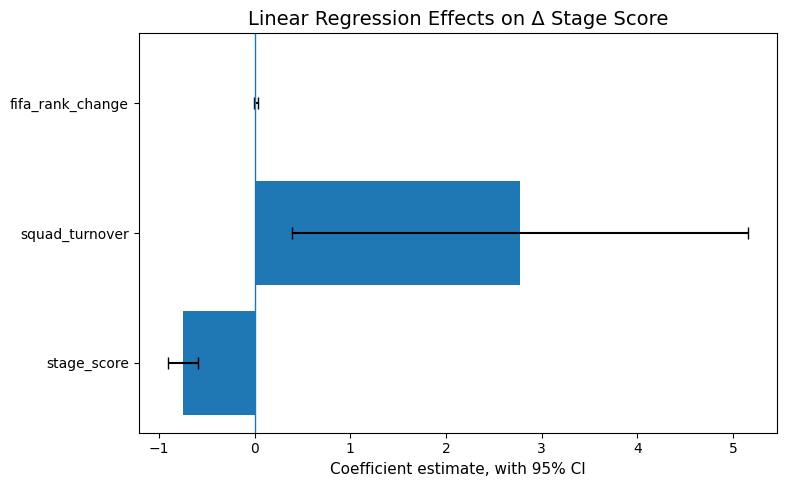

In [24]:
# Chart 8: Linear regression coefficients for Question 4
coef = q4_model.params.drop('Intercept')
conf = q4_model.conf_int().loc[coef.index]
err_low = coef - conf[0]
err_high = conf[1] - coef

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef.index, coef.values, xerr=[err_low.values, err_high.values], capsize=4)
ax.axvline(0, linewidth=1)
ax.set_title('Linear Regression Effects on Δ Stage Score')
ax.set_xlabel('Coefficient estimate, with 95% CI')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_linear_coefficients.png', dpi=200, bbox_inches='tight')
plt.show()

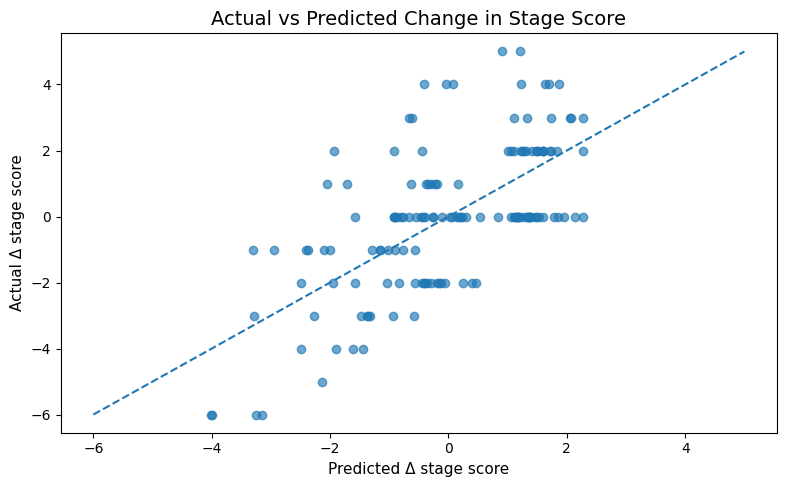

In [25]:
# Chart 9: Actual vs fitted Δ stage score
q4_plot = q4.copy()
q4_plot['fitted_delta'] = q4_model.predict(q4_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(q4_plot['fitted_delta'], q4_plot['delta_stage'], alpha=0.65)
min_val = min(q4_plot['fitted_delta'].min(), q4_plot['delta_stage'].min())
max_val = max(q4_plot['fitted_delta'].max(), q4_plot['delta_stage'].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--')
ax.set_title('Actual vs Predicted Change in Stage Score')
ax.set_xlabel('Predicted Δ stage score')
ax.set_ylabel('Actual Δ stage score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_actual_vs_predicted_delta.png', dpi=200, bbox_inches='tight')
plt.show()

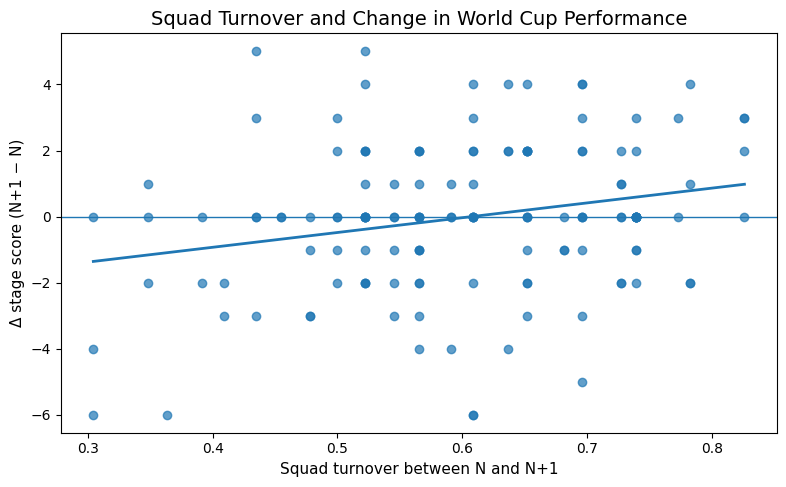

In [26]:
# Chart 10: Squad turnover versus performance change
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(q4['squad_turnover'], q4['delta_stage'], alpha=0.7)
# Simple fitted line for visualization only
line_model = smf.ols('delta_stage ~ squad_turnover', data=q4).fit()
xs = np.linspace(q4['squad_turnover'].min(), q4['squad_turnover'].max(), 100)
ys = line_model.params['Intercept'] + line_model.params['squad_turnover'] * xs
ax.plot(xs, ys, linewidth=2)
ax.axhline(0, linewidth=1)
ax.set_title('Squad Turnover and Change in World Cup Performance')
ax.set_xlabel('Squad turnover between N and N+1')
ax.set_ylabel('Δ stage score (N+1 − N)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '10_squad_turnover_delta.png', dpi=200, bbox_inches='tight')
plt.show()

## Final summary and export

In [27]:
summary_for_deck = {
    'n_pairs': int(len(pairs)),
    'n_teams': int(pairs['team_key'].nunique()),
    'share_underperform': float(pairs['underperform_next'].mean()),
    'q1_expectation_residual_coef': float(q1_logit.params['expectation_residual']),
    'q1_expectation_residual_p': float(q1_logit.pvalues['expectation_residual']),
    'q1_expectation_residual_or': float(np.exp(q1_logit.params['expectation_residual'])),
    'q1_exceeded_expectations_or': float(np.exp(q1_binary.params['exceeded_expectations'])),
    'q1_exceeded_expectations_p': float(q1_binary.pvalues['exceeded_expectations']),
    'q2_anova_p': float(p_val) if 'p_val' in globals() else None,
    'q2_champion_mean_delta': float(q2_summary.loc['Champion', 'mean']),
    'q2_runnerup_mean_delta': float(q2_summary.loc['Runner-up', 'mean']),
    'q2_semifinalist_mean_delta': float(q2_summary.loc['Semifinalist', 'mean']),
    'q3_full_stage_coef': float(ord_full_res.params['stage_score']),
    'q3_full_stage_p': float(ord_full_res.pvalues['stage_score']),
    'q3_ranked_stage_coef': float(ord_ranked_res.params['stage_score']),
    'q3_ranked_stage_p': float(ord_ranked_res.pvalues['stage_score']),
    'q4_stage_coef': float(q4_model.params['stage_score']),
    'q4_stage_p': float(q4_model.pvalues['stage_score']),
    'q4_r2': float(q4_model.rsquared),
    'q4_n': int(len(q4))
}

with open(OUTPUT_DIR / 'summary_for_deck.json', 'w') as f:
    json.dump(summary_for_deck, f, indent=2)

pairs.to_csv(OUTPUT_DIR / 'world_cup_hangover_pairs_processed.csv', index=False)
ranked_pairs.to_csv(OUTPUT_DIR / 'world_cup_hangover_ranked_pairs.csv', index=False)

print(json.dumps(summary_for_deck, indent=2))
print('\nCharts and processed data saved to:', OUTPUT_DIR.resolve())

{
  "n_pairs": 457,
  "n_teams": 83,
  "share_underperform": 0.5886214442013129,
  "q1_expectation_residual_coef": 0.5870646333544045,
  "q1_expectation_residual_p": 1.8551812411266116e-07,
  "q1_expectation_residual_or": 1.7987008122978096,
  "q1_exceeded_expectations_or": 4.762697026134953,
  "q1_exceeded_expectations_p": 5.656243678530261e-07,
  "q2_anova_p": 0.31301731545914097,
  "q2_champion_mean_delta": -3.5714285714285716,
  "q2_runnerup_mean_delta": -2.6666666666666665,
  "q2_semifinalist_mean_delta": -2.6666666666666665,
  "q3_full_stage_coef": 0.29479210688657354,
  "q3_full_stage_p": 3.291890898457205e-10,
  "q3_ranked_stage_coef": 0.19272982501473326,
  "q3_ranked_stage_p": 0.016683611352139683,
  "q4_stage_coef": -0.7507324078177287,
  "q4_stage_p": 1.7950851885520077e-16,
  "q4_r2": 0.4317458459785769,
  "q4_n": 144
}

Charts and processed data saved to: /Users/weizichen/Downloads/wc_hangover_charts


## Suggested presentation conclusions

1. **Expectation overperformance:** Teams that exceeded their expected stage based on FIFA ranking had higher odds of underperforming in the next World Cup.
2. **Elite-team comparison:** Champions had the largest average next-tournament drop, but ANOVA did not show a statistically significant difference between champions, runners-up, and semifinalists.
3. **Ordinal regression:** Stage reached in tournament N positively predicted stage reached in N+1, so the strict version of the hangover hypothesis was not supported.
4. **Performance change model:** Higher stage reached in N strongly predicted a more negative Δ stage score, supporting a regression-to-the-mean version of the hangover hypothesis.

**Important limitation:** FIFA rankings only begin in December 1992, so ranking-based models use a smaller post-1992 subset. Squad turnover is only available when the same team qualified for both consecutive tournaments.